In [1]:
library(data.table)
library(dplyr) 
library(stringr) 
library(plyr)
library(ggpubr)

setwd("/gpfs/commons/groups/knowles_lab/Karin/PCDH/featureCounts")

# Read in the featureCounts output
counts = list.files(pattern = "multimapping_counts.txt")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


------------------------------------------------------------------------------

You have loaded plyr after dplyr - this is likely to cause problems.
If you need functions from both plyr and dplyr, please load plyr first, then dplyr:
library(plyr); library(dplyr)

------------------------------------------------------------------------------


Attaching package: ‘plyr’


The following objects are masked from ‘package:dplyr’:

    arrange, count, desc, failwith, id, mutate, rename, summarise,
    summarize


Loading required package: ggplot2


Attaching package: ‘ggpubr’


The following object is masked from ‘package:plyr’:

    mutate




In [2]:
counts

[1] "Brain_Myeloid_macrophage_multimapping_counts.txt"                                
 [2] "Brain_Myeloid_macrophage_multimapping_counts.txt.summary"                        
 [3] "Brain_Myeloid_microglial_cell_multimapping_counts.txt"                           
 [4] "Brain_Myeloid_microglial_cell_multimapping_counts.txt.summary"                   
 [5] "Brain_Non-Myeloid_astrocyte_multimapping_counts.txt"                             
 [6] "Brain_Non-Myeloid_astrocyte_multimapping_counts.txt.summary"                     
 [7] "Brain_Non-Myeloid_Bergmann_glial_cell_multimapping_counts.txt"                   
 [8] "Brain_Non-Myeloid_Bergmann_glial_cell_multimapping_counts.txt.summary"           
 [9] "Brain_Non-Myeloid_brain_pericyte_multimapping_counts.txt"                        
[10] "Brain_Non-Myeloid_brain_pericyte_multimapping_counts.txt.summary"                
[11] "Brain_Non-Myeloid_endothelial_cell_multimapping_counts.txt"                      
[12] "Brain_Non-Myeloid_endothelial_cell_multimapping_counts.txt.summary"              
[13] "Brain_Non-Myeloid_neuron_multimapping_counts.txt"                                
[14] "Brain_Non-Myeloid_neuron_multimapping_counts.txt.summary"                        
[15] "Brain_Non-Myeloid_oligodendrocyte_multimapping_counts.txt"                       
[16] "Brain_Non-Myeloid_oligodendrocyte_multimapping_counts.txt.summary"               
[17] "Brain_Non-Myeloid_oligodendrocyte_precursor_cell_multimapping_counts.txt"        
[18] "Brain_Non-Myeloid_oligodendrocyte_precursor_cell_multimapping_counts.txt.summary"

In [3]:
get_counts = function(file_name){
    if(!(str_detect(file_name, "summary"))){
        f = fread(file_name)
        f$Length = NULL 
        f = melt(f) 
        f$cell_type = paste((unlist(strsplit(file_name, "_")))[1:length(unlist(strsplit(file_name, "_")))-1], collapse="_")
        return(f)
    }
}

In [4]:
all_genes= as.data.table(ldply(llply(counts, get_counts)))

Warning message in melt.data.table(f):
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns [Geneid, Chr, Start, End, ...]. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in melt.data.table(f):
“'measure.vars' [Brain_Myeloid_macrophage/A10-MAA000604-3_10_M-1-1_merged.mus.Aligned.out.sorted.CB.bam, Brain_Myeloid_macrophage/A7-MAA000604-3_10_M-1-1_merged.mus.Aligned.out.sorted.CB.bam, Brain_Myeloid_macrophage/B19-MAA000605-3_10_M-1-1_merged.mus.Aligned.out.sorted.CB.bam, Brain_Myeloid_macrophage/B8-B003279-3_38_F-1-1_merged.mus.Aligned.out.sorted.CB.bam, ...] are not all of the same type. By order of hierarchy, the molten data value column will be of type 'double'. All measure variables not of type 'double' will be coerced too. Check DETAILS in ?melt.data.table for more on coercion.”


Warning message in melt.data.table(f):
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns [Geneid, Chr, Start, End, ...]. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in melt.data.table(f):
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns [Geneid, Chr, Start, End, ...]. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in melt.data.table(f):
“'measure.vars' [Brain_Non-Myeloid_astrocyte/A10-MAA000926-3_9_M-1-1_merged.mus.Aligned.out.sorted.CB.bam, Brain_Non-Myeloid_astrocyte/A11-B000404-3_56_F-1-1_merged.mus.Aligned.out.sorted.CB.bam, Brain_Non-Myeloid_astrocyte/A11-MAA000923-3_9_M-1-1_merged.mus.Aligned.out.sorted.CB.bam, Brain_Non-Myeloid_astrocyte/A11-MAA000944-3_9_M-1-1

In [5]:
expressed = filter(all_genes, value > 0)
head(expressed)

Geneid,Chr,Start,End,Strand,variable,value,cell_type
<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>,<chr>
PCDHA9,chr18,36997880,37000360,+,Brain_Myeloid_macrophage/B19-MAA000605-3_10_M-1-1_merged.mus.Aligned.out.sorted.CB.bam,2.0,Brain_Myeloid_macrophage_multimapping
PCDHB7,chr18,37341813,37344302,+,Brain_Myeloid_macrophage/C20-B003279-3_38_F-1-1_merged.mus.Aligned.out.sorted.CB.bam,3.5,Brain_Myeloid_macrophage_multimapping
PCDHB19,chr18,37497154,37499559,+,Brain_Myeloid_macrophage/C20-B003279-3_38_F-1-1_merged.mus.Aligned.out.sorted.CB.bam,0.5,Brain_Myeloid_macrophage_multimapping
PCDHGB4,chr18,37720554,37722917,+,Brain_Myeloid_macrophage/F15-MAA000570-3_8_M-1-1_merged.mus.Aligned.out.sorted.CB.bam,2.5,Brain_Myeloid_macrophage_multimapping
PCDHGB5,chr18,37731154,37733559,+,Brain_Myeloid_macrophage/F15-MAA000570-3_8_M-1-1_merged.mus.Aligned.out.sorted.CB.bam,742.5,Brain_Myeloid_macrophage_multimapping
PCDHGB6,chr18,37742241,37744658,+,Brain_Myeloid_macrophage/F15-MAA000570-3_8_M-1-1_merged.mus.Aligned.out.sorted.CB.bam,4.0,Brain_Myeloid_macrophage_multimapping


In [6]:
unique(expressed$Geneid)

[1] "PCDHA9"                          "PCDHB7"                         
 [3] "PCDHB19"                         "PCDHGB4"                        
 [5] "PCDHGB5"                         "PCDHGB6"                        
 [7] "PCDHGB1"                         "PCDHGB2"                        
 [9] "PCDHGA4"                         "PCDHGC3"                        
[11] "ThirdConstantExon"               "PCDHB9"                         
[13] "PCDHGB7"                         "PCDHGA11"                       
[15] "PCDHB22"                         "PCDHGA12"                       
[17] "PCDHGA7"                         "PCDHB17"                        
[19] "PCDHGA5"                         "PCDHGC4"                        
[21] "PCDHGA10"                        "PCDHGA6"                        
[23] "PCDHGA3"                         "PCDHGA1"                        
[25] "PCDHAC1"                         "PCDHGA2"                        
[27] "PCDHGA8"                         "PCDHB4"                         
[29] "PCDHGC5"                         "PCDHA5"                         
[31] "PCDHB14"                         "PCDHA11"                        
[33] "PCDHGA9"                         "SecondConstantExon"             
[35] "FirstConstantExon"               "PCDHB8"                         
[37] "PCDHB10"                         "PCDHB20"                        
[39] "PCDHB16"                         "PCDHB12"                        
[41] "PCDHB13"                         "PCDHB1"                         
[43] "PCDHB3"                          "PCDHB18"                        
[45] "PCDHB21"                         "PCDHA8"                         
[47] "PCDHB5"                          "PCDHA4"                         
[49] "PCDHB6"                          "BTypeUniqueThirdConstantExon"   
[51] "PCDHB15"                         "PCDHA12"                        
[53] "PCDHA7"                          "PCDHA3"                         
[55] "PCDHB2"                          "PCDHB11"                        
[57] "PCDHAC2"                         "ATypeUniqueThirdConstantExon"   
[59] "PCDHA2"                          "PCDHA6"                         
[61] "PCDHA10"                         "SharedregionofThirdConstantExon"
[63] "PCDHA1"

In [25]:
neurons=filter(expressed, cell_type == "Brain_Non-Myeloid_neuron_multimapping", Geneid %in% c("ATypeUniqueThirdConstantExon", "BTypeUniqueThirdConstantExon", "SharedregionofThirdConstantExon"))
head(neurons)

Geneid,Chr,Start,End,Strand,variable,value,cell_type
<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>,<chr>
SharedregionofThirdConstantExon,chr18,37184946,37185047,+,Brain_Non-Myeloid_neuron/A12-MAA000615-3_10_M-1-1_merged.mus.Aligned.out.sorted.CB.bam,2,Brain_Non-Myeloid_neuron_multimapping
ATypeUniqueThirdConstantExon,chr18,37185048,37185256,+,Brain_Non-Myeloid_neuron/A12-MAA000615-3_10_M-1-1_merged.mus.Aligned.out.sorted.CB.bam,4,Brain_Non-Myeloid_neuron_multimapping
SharedregionofThirdConstantExon,chr18,37184946,37185047,+,Brain_Non-Myeloid_neuron/A14-MAA000561-3_10_M-1-1_merged.mus.Aligned.out.sorted.CB.bam,2,Brain_Non-Myeloid_neuron_multimapping
ATypeUniqueThirdConstantExon,chr18,37185048,37185256,+,Brain_Non-Myeloid_neuron/A14-MAA000561-3_10_M-1-1_merged.mus.Aligned.out.sorted.CB.bam,17,Brain_Non-Myeloid_neuron_multimapping
BTypeUniqueThirdConstantExon,chr18,37185476,37185546,+,Brain_Non-Myeloid_neuron/A14-MAA000561-3_10_M-1-1_merged.mus.Aligned.out.sorted.CB.bam,17,Brain_Non-Myeloid_neuron_multimapping
ATypeUniqueThirdConstantExon,chr18,37185048,37185256,+,Brain_Non-Myeloid_neuron/A14-MAA000942-3_8_M-1-1_merged.mus.Aligned.out.sorted.CB.bam,11,Brain_Non-Myeloid_neuron_multimapping


In [23]:
library("EnvStats")


Attaching package: ‘EnvStats’


The following objects are masked from ‘package:stats’:

    predict, predict.lm




In [9]:
t=filter(as.data.table(table(expressed$Geneid, expressed$cell_type)), N > 0)
filter(t, V1 %in% c("ATypeUniqueThirdConstantExon", "BTypeUniqueThirdConstantExon", "SharedregionofThirdConstantExon"))

V1,V2,N
<chr>,<chr>,<int>
BTypeUniqueThirdConstantExon,Brain_Myeloid_microglial_cell_multimapping,1
ATypeUniqueThirdConstantExon,Brain_Non-Myeloid_astrocyte_multimapping,3
BTypeUniqueThirdConstantExon,Brain_Non-Myeloid_astrocyte_multimapping,2
ATypeUniqueThirdConstantExon,Brain_Non-Myeloid_Bergmann_glial_cell_multimapping,1
SharedregionofThirdConstantExon,Brain_Non-Myeloid_Bergmann_glial_cell_multimapping,1
ATypeUniqueThirdConstantExon,Brain_Non-Myeloid_brain_pericyte_multimapping,10
BTypeUniqueThirdConstantExon,Brain_Non-Myeloid_brain_pericyte_multimapping,5
SharedregionofThirdConstantExon,Brain_Non-Myeloid_brain_pericyte_multimapping,2
ATypeUniqueThirdConstantExon,Brain_Non-Myeloid_endothelial_cell_multimapping,3


In [38]:
getwd()

[1] "/gpfs/commons/groups/knowles_lab/Karin/PCDH/featureCounts"

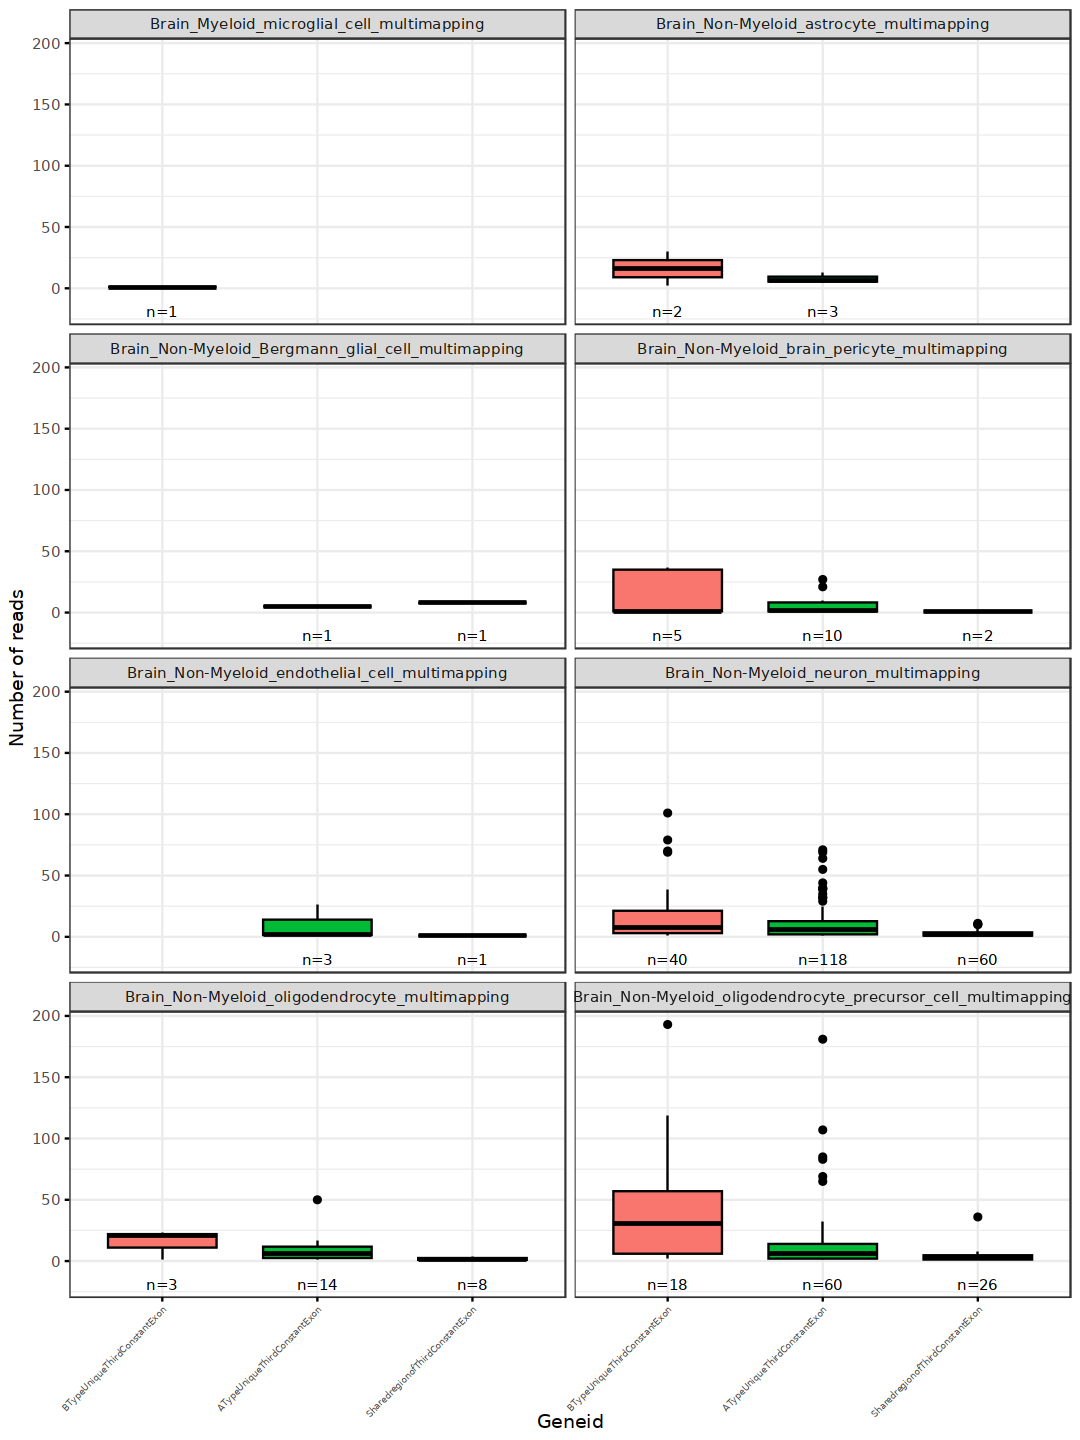

In [37]:
options(repr.plot.width=9, repr.plot.height=12)

cell_data = filter(expressed, Geneid %in% c("ATypeUniqueThirdConstantExon", "BTypeUniqueThirdConstantExon", "SharedregionofThirdConstantExon"))
g=ggboxplot(cell_data, x="Geneid", y="value", jitter=TRUE, fill="Geneid")+theme_bw()
g=ggpar(g, legend="none", x.text.angle=45)
# decrease font of xaxis ticks 
g = g+theme(axis.text.x = element_text(size=5))+ylab("Number of reads")+stat_n_text(size=3)
# facet by cell type 
g = g+facet_wrap(~cell_type, ncol=2)
g
# save plot 
ggsave("PCDH_counts.pdf", g, width=9, height=12)

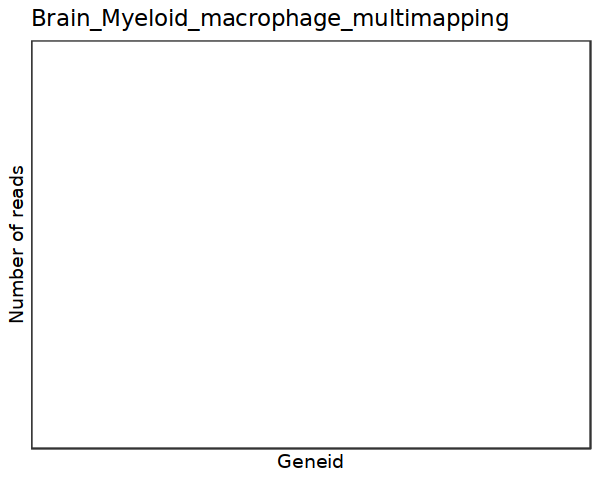

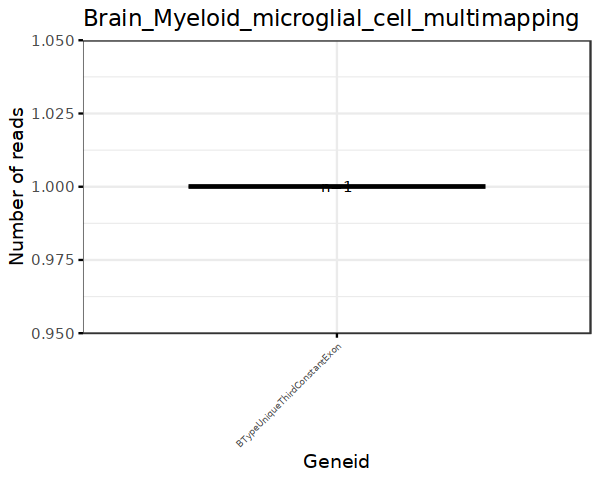

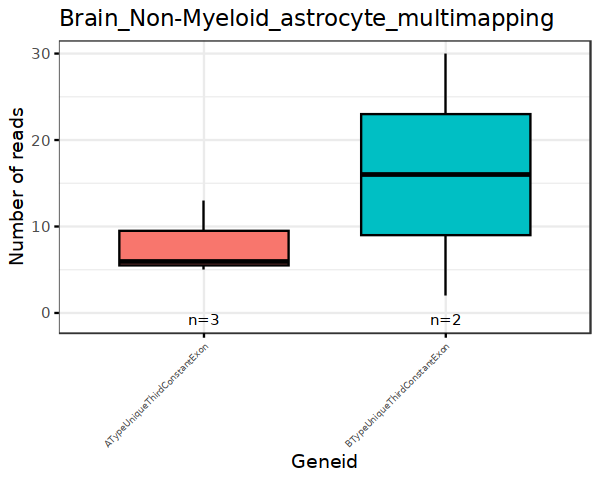

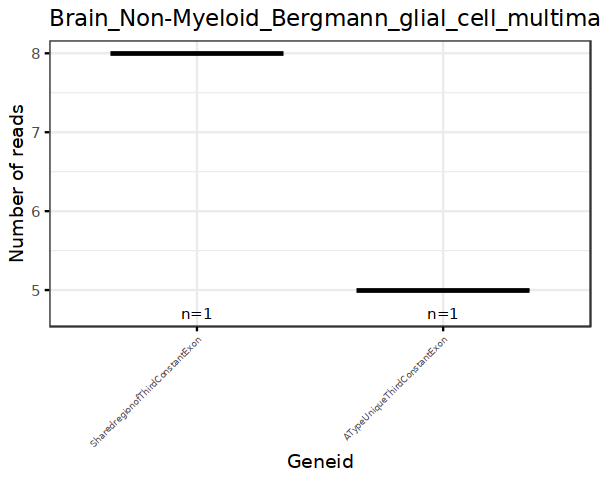

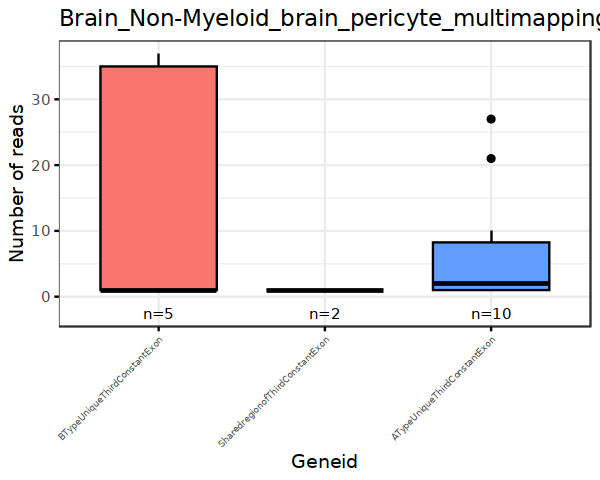

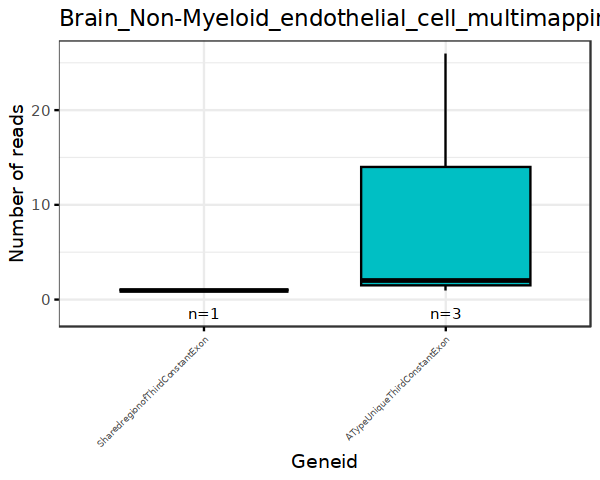

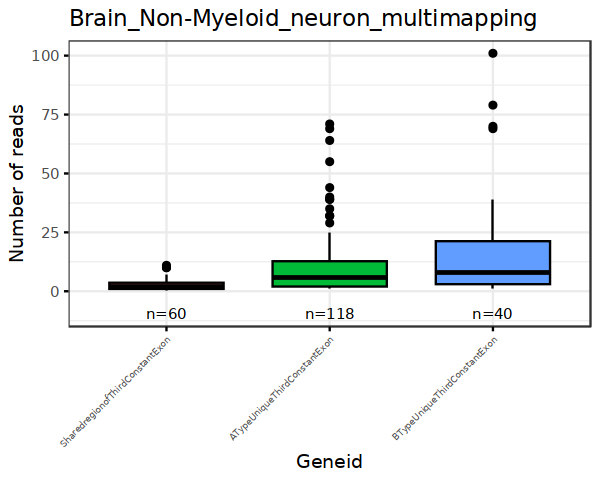

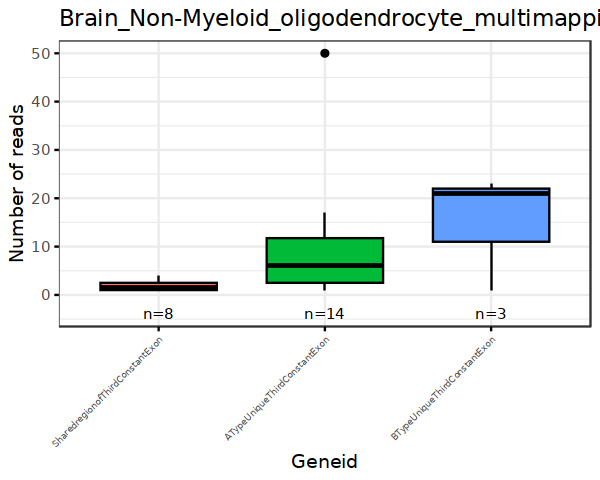

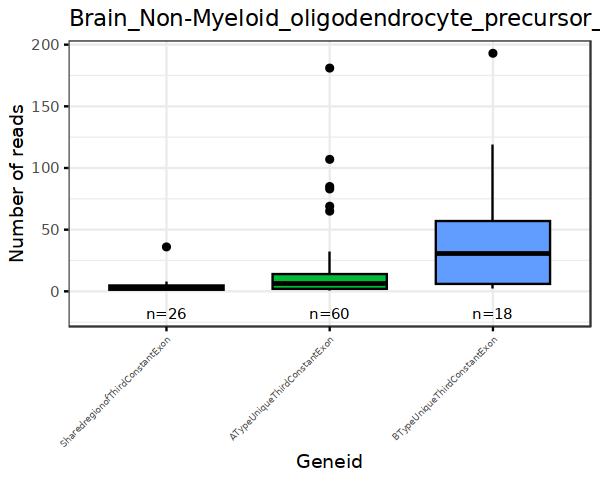

In [29]:
# make each plot smaller 
options(repr.plot.width=5, repr.plot.height=4)

for(cell in unique(expressed$cell_type)){
    cell_data = filter(expressed, cell_type ==cell, Geneid %in% c("ATypeUniqueThirdConstantExon", "BTypeUniqueThirdConstantExon", "SharedregionofThirdConstantExon"))
    g=ggboxplot(cell_data, x="Geneid", y="value", jitter=TRUE, fill="Geneid")+theme_bw()
    g=ggpar(g, legend="none", x.text.angle=45)
    # decrease font of xaxis ticks 
    g = g+theme(axis.text.x = element_text(size=5))+ylab("Number of reads")+stat_n_text(size=3)
    # add title to be cell 
    g = g+ggtitle(cell)
    print(g)
}